In [170]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, roc_auc_score, f1_score, roc_curve, classification_report, 
                             cohen_kappa_score, make_scorer)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.svm import SVC



#suppress convergence warnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")

In [171]:
cannabis = pd.read_csv("cannabis_full.csv")
cannabis.dropna(inplace = True)

# Part One: Binary Classification

Create a dataset that is limited only to the Sativa and Indica type cannabis strains.


In [172]:
# filter dataset
filtered_data = cannabis[(cannabis["Type"] == "sativa") | (cannabis["Type"] == "indica")]
filtered_data = filtered_data.drop(["Effects", "Flavor"], axis = 1)

This section asks you to create a final best model for each of the four new model types studied this week: LDA, QDA, SVC, and SVM. For SVM, you may limit yourself to only the polynomial kernel.

For each, you should:

Choose a metric you will use to select your model, and briefly justify your choice. (Hint: There is no specific target category here, so this should not be a metric that only prioritizes one category.)

* Find the best model for predicting the Type variable. Don’t forget to tune any hyperparameters.

* Report the (cross-validated!) metric.

* Fit the final model.

* Output a confusion matrix.


The metric that will be used in this evaluation is a f1-score. F1 is a good metric to use because it balances both precision and recall, providing a more comprehensive evaluation of model performance, especially in cases with class imbalances.

In [173]:
X = filtered_data.drop(["Type", "Strain"], axis = 1)
y = filtered_data["Type"]

# make y dummy vars
y = y.map({'sativa': 0, 'indica': 1}).astype(float)

filtered_data['Type'].value_counts()

Type
indica    659
sativa    409
Name: count, dtype: int64

In [174]:

def get_metrics(X, y, model_type):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify = y)

    # Initialize model and params
    if model_type == "LDA":
        model = LinearDiscriminantAnalysis()
        params = {"model__solver": ['svd', 'lsqr']}
    elif model_type == "QDA":
        model = QuadraticDiscriminantAnalysis()
        params = {'model__reg_param': [0.0, 0.1, 0.2, 0.5, 1.0]}
    elif model_type == "SVC":
        model = SVC()
        params = {'model__kernel': ['linear', 'poly', 'rbf'], 'model__C': [0.1, 1, 10], 
                  'model__gamma': ['scale', 'auto']}
    elif model_type == "SVM":
        model = SVC()
        params = {'model__kernel': ['poly'], 'model__C': [0.1, 1, 10], 'model__degree': [3, 4, 5]}
    elif model_type == "KNN":
        model = KNeighborsClassifier()
        params = {
            'model__n_neighbors': range(3, 30),
            'model__weights': ['uniform', 'distance'], 
            'model__metric': ['euclidean', 'manhattan', 'minkowski']
        }
    elif model_type == "log":
        model = LogisticRegression()
        params = {'model__C': [0.01, 0.1, 1, 10, 100]}
    # Define preprocessing pipeline
    ct = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), ["Rating"])],
        remainder = "passthrough"
    )

    # Build pipeline with column transformer and model
    pipeline = Pipeline([
        ('preprocessor', ct),
        ('model', model)
    ])

    # Perform Grid Search for hyperparameter tuning
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, scoring='f1_macro', n_jobs = -1)
    grid_search.fit(X_train, y_train)

    # Get the best model and best parameters
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    print(f"Best Model: {best_params}")

    # Cross-validation to get F1 score
    cv_f1 = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_macro').mean()
    print(f"Cross-validated F1 score: {cv_f1:.4f}")

    # Fit the final model on the whole training set
    best_model.fit(X_train, y_train)

    # Predict on the test set and calculate confusion matrix
    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print("Class Order:", best_model.classes_)
    print("Confusion Matrix:")
    print(cm)

    return



## LDA

In [175]:
# calculate for LDA
get_metrics(X, y, model_type = "LDA")

Best Model: {'model__solver': 'lsqr'}
Cross-validated F1 score: 0.8532
Class Order: [0. 1.]
Confusion Matrix:
[[ 60  22]
 [ 21 111]]
Best Model: {'model__solver': 'lsqr'}
Cross-validated F1 score: 0.8532
Class Order: [0. 1.]
Confusion Matrix:
[[ 60  22]
 [ 21 111]]


## QDA

In [176]:
get_metrics(X, y, model_type = "QDA")

/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonPro

Best Model: {'model__reg_param': 0.1}
Cross-validated F1 score: 0.8532
Best Model: {'model__reg_param': 0.1}
Cross-validated F1 score: 0.8532


Class Order: [0. 1.]
Confusion Matrix:
[[ 66  16]
 [ 17 115]]
Class Order: [0. 1.]
Confusion Matrix:
[[ 66  16]
 [ 17 115]]


## SVC

In [177]:
get_metrics(X, y, model_type = "SVC")

Best Model: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Cross-validated F1 score: 0.8630
Class Order: [0. 1.]
Confusion Matrix:
[[ 67  15]
 [ 20 112]]
Best Model: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Cross-validated F1 score: 0.8630
Class Order: [0. 1.]
Confusion Matrix:
[[ 67  15]
 [ 20 112]]


## SVM

In [178]:
get_metrics(X, y, model_type = "SVM")

Best Model: {'model__C': 1, 'model__degree': 3, 'model__kernel': 'poly'}
Cross-validated F1 score: 0.8571
Class Order: [0. 1.]
Confusion Matrix:
[[ 64  18]
 [ 18 114]]
Best Model: {'model__C': 1, 'model__degree': 3, 'model__kernel': 'poly'}
Cross-validated F1 score: 0.8571
Class Order: [0. 1.]
Confusion Matrix:
[[ 64  18]
 [ 18 114]]


# Part Two: Natural Multiclass

Now use the full dataset, including the Hybrid strains.

## Q1 
Fit a decision tree, plot the final fit, and interpret the results.

Best Parameters:
 {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best Parameters:
 {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


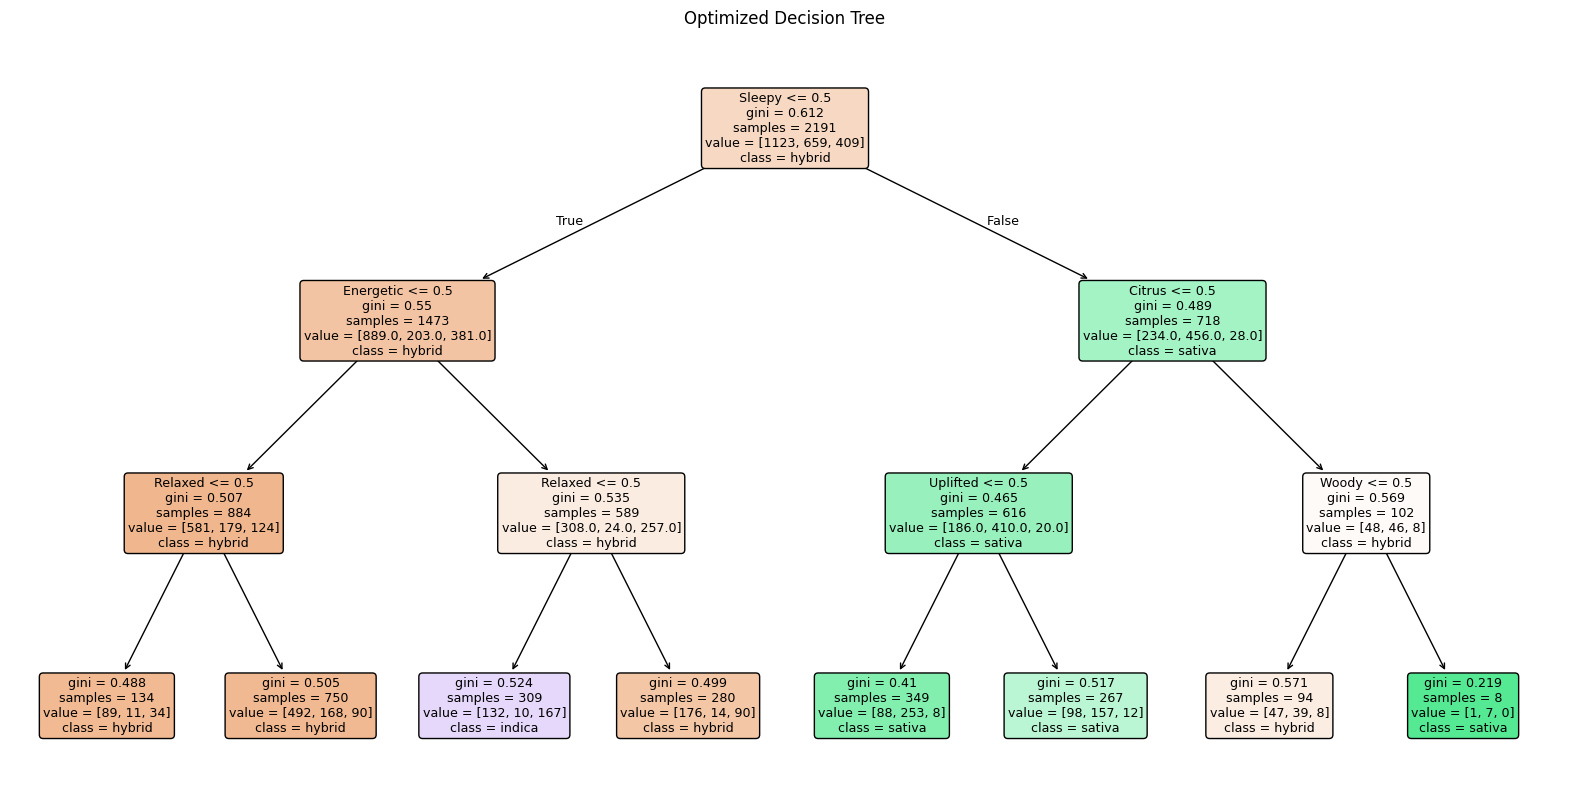

In [179]:
# select columns
data2  = cannabis.drop(["Strain", "Effects", "Flavor"], axis = 1)

X = data2.drop(["Type"], axis = 1)
y = data2["Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify = y)

ct = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), ["Rating"])],
        remainder = "passthrough"
    )

# Set up the pipeline
pipeline = Pipeline([
    ("preprocessing", ct),
    ("classifier", DecisionTreeClassifier(random_state=1))
])

# Define hyperparameters to tune
param_grid = {
    "classifier__max_depth": [3, 5, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}


# perform grid search
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')
    grid_search.fit(X, y)

# Get the best model
best_params = grid_search.best_params_
print("Best Parameters:\n", best_params)

# Extract the fitted tree
best_tree = grid_search.best_estimator_.named_steps['classifier']
class_names = y.unique()

# Plot the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.title("Optimized Decision Tree")
plt.show()


The decision tree splits the data based on the feature "sleepy", where the threshold is 0.5. The resulting nodes have varying Gini index values, generally falling between 0.41 and 0.55, except for the initial split. A lower Gini index indicates a purer split, meaning that most samples in the resulting nodes belong to a single class. The initial split likely has a higher Gini value because it separates the data into broad groups, with more specific splits refining class separation further down the tree.

## Q2
Repeat the analyses from Part One for LDA, QDA, and KNN.

### LDA

In [180]:
get_metrics(X, y, model_type = "LDA")

Best Model: {'model__solver': 'svd'}
Best Model: {'model__solver': 'svd'}


Cross-validated F1 score: 0.5934
Class Order: ['hybrid' 'indica' 'sativa']
Confusion Matrix:
[[147  46  32]
 [ 41  88   3]
 [ 42   3  37]]
Cross-validated F1 score: 0.5934
Class Order: ['hybrid' 'indica' 'sativa']
Confusion Matrix:
[[147  46  32]
 [ 41  88   3]
 [ 42   3  37]]


### QDA

In [181]:
get_metrics(X, y, model_type = "QDA")

/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonPro

/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonProject/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/chloefeehan/.conda/envs/pythonPro

Best Model: {'model__reg_param': 0.1}
Best Model: {'model__reg_param': 0.1}


Cross-validated F1 score: 0.5761
Class Order: ['hybrid' 'indica' 'sativa']
Confusion Matrix:
[[115  72  38]
 [ 24 106   2]
 [ 33   6  43]]
Cross-validated F1 score: 0.5761
Class Order: ['hybrid' 'indica' 'sativa']
Confusion Matrix:
[[115  72  38]
 [ 24 106   2]
 [ 33   6  43]]


### KNN

In [182]:
get_metrics(X, y, model_type = "KNN")

Best Model: {'model__metric': 'manhattan', 'model__n_neighbors': 14, 'model__weights': 'distance'}
Cross-validated F1 score: 0.5410
Class Order: ['hybrid' 'indica' 'sativa']
Confusion Matrix:
[[162  41  22]
 [ 58  73   1]
 [ 50   4  28]]
Best Model: {'model__metric': 'manhattan', 'model__n_neighbors': 14, 'model__weights': 'distance'}
Cross-validated F1 score: 0.5410
Class Order: ['hybrid' 'indica' 'sativa']
Confusion Matrix:
[[162  41  22]
 [ 58  73   1]
 [ 50   4  28]]


## Q3
Were your metrics better or worse than in Part One? Why? Which categories were most likely to get mixed up, according to the confusion matrices? Why?

The F1 scores significantly dropped to the 0.5-0.6 range in Part 2, compared to the 0.8 range in Part 1. This suggests a decline in model performance after adding the Hybrid class. The most likely cause of this drop is that the Indica and Hybrid classes were often misclassified, as indicated by the higher number of false positives and false negatives in the confusion matrix, especially when compared to Sativa. The misclassifications could stem from the overlap in features between Indica and Hybrid, such as flavor profiles or effects, which are more similar than those of Sativa. This shared characteristic likely made it more difficult for the model to distinguish between these two classes, leading to decreased accuracy and F1 scores.


# Part Three: Multiclass from Binary
Consider two models designed for binary classification: SVC and Logistic Regression.

## Q1

Fit and report metrics for OvR versions of the models. That is, for each of the two model types, create three models:

* Indica vs. Not Indica

* Sativa vs. Not Sativa

* Hybrid vs. Not Hybrid

In [183]:
# Define your X and y
data2  = cannabis.drop(["Strain", "Effects", "Flavor"], axis = 1)

X = data2.drop(["Type"], axis = 1)
y = data2["Type"]

y_indica = (y == 'indica').astype(int)
y_sativa = (y == 'sativa').astype(int)
y_hybrid = (y == 'hybrid').astype(int) 



### Indica vs. Not Indica

#### SVC

In [184]:
get_metrics(X, y_indica, model_type = "SVC")

Best Model: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best Model: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}


Cross-validated F1 score: 0.7563
Class Order: [0 1]
Confusion Matrix:
[[246  61]
 [ 38  94]]
Cross-validated F1 score: 0.7563
Class Order: [0 1]
Confusion Matrix:
[[246  61]
 [ 38  94]]


#### Logistic Regression

In [185]:
get_metrics(X, y_indica, model_type = "log")

Best Model: {'model__C': 1}
Cross-validated F1 score: 0.7542
Class Order: [0 1]
Confusion Matrix:
[[262  45]
 [ 47  85]]
Best Model: {'model__C': 1}
Cross-validated F1 score: 0.7542
Class Order: [0 1]
Confusion Matrix:
[[262  45]
 [ 47  85]]


### Sativa vs. Not Sativa

#### SVC

In [186]:
get_metrics(X, y_sativa, model_type = "SVC")

Best Model: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Model: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Cross-validated F1 score: 0.6645
Class Order: [0 1]
Confusion Matrix:
[[324  33]
 [ 54  28]]
Cross-validated F1 score: 0.6645
Class Order: [0 1]
Confusion Matrix:
[[324  33]
 [ 54  28]]


#### Logistic Regression

In [187]:
get_metrics(X, y_sativa, model_type = "log")

Best Model: {'model__C': 100}
Cross-validated F1 score: 0.6504
Class Order: [0 1]
Confusion Matrix:
[[331  26]
 [ 53  29]]
Best Model: {'model__C': 100}
Cross-validated F1 score: 0.6504
Class Order: [0 1]
Confusion Matrix:
[[331  26]
 [ 53  29]]


### Hybrid vs. Not Hybrid

#### SVC

In [188]:
get_metrics(X, y_hybrid, model_type = "SVC")

Best Model: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Model: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Cross-validated F1 score: 0.6314
Cross-validated F1 score: 0.6314


Class Order: [0 1]
Confusion Matrix:
[[119  95]
 [ 69 156]]
Class Order: [0 1]
Confusion Matrix:
[[119  95]
 [ 69 156]]


#### Logistic Regression

In [189]:
get_metrics(X, y_hybrid, model_type = "log")

Best Model: {'model__C': 0.1}
Cross-validated F1 score: 0.6289
Class Order: [0 1]
Confusion Matrix:
[[115  99]
 [ 71 154]]
Best Model: {'model__C': 0.1}
Cross-validated F1 score: 0.6289
Class Order: [0 1]
Confusion Matrix:
[[115  99]
 [ 71 154]]


## Q2
Which of the six models did the best job distinguishing the target category from the rest? Which did the worst? Does this make intuitive sense?

The F1 scores dropped significantly to the 0.5-0.6 range in Part 2, compared to the 0.8 range in Part 1, suggesting a decline in model performance after introducing the Hybrid class. This decrease in performance can likely be attributed to the frequent misclassification of the Indica and Hybrid classes, as evidenced by the higher number of false positives and false negatives in the confusion matrices, especially when compared to Sativa. The misclassifications between Indica and Hybrid may be due to overlapping feature characteristics, such as flavor profiles or effects, which are more similar between these two classes than with Sativa. This overlap likely made it harder for the model to distinguish between Indica and Hybrid, leading to a decline in classification accuracy and F1 scores.

## Q3
Fit and report metrics for OvO versions of the models. That is, for each of the two model types, create three models:

* Indica vs. Sativa

* Indica vs. Hybrid

* Hybrid vs. Sativa


In [190]:
# Indica vs. Sativa
y_indsat = (y.isin(['indica', 'sativa'])).astype(int)

# Indica vs. Hybrid
y_indhyb = (y.isin(['indica', 'hybrid'])).astype(int)

# Sativa vs. Hybrid
y_hybsat = (y.isin(['sativa', 'hybrid'])).astype(int)




### Indica vs. Sativa

#### SVC



In [191]:
get_metrics(X, y_indsat, model_type = "SVC")

Best Model: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Model: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


Cross-validated F1 score: 0.6383
Cross-validated F1 score: 0.6383


Class Order: [0 1]
Confusion Matrix:
[[142  83]
 [ 86 128]]
Class Order: [0 1]
Confusion Matrix:
[[142  83]
 [ 86 128]]


#### Logistic Regression

In [192]:
get_metrics(X, y_indsat, model_type = "log")

Best Model: {'model__C': 10}
Cross-validated F1 score: 0.6320
Class Order: [0 1]
Confusion Matrix:
[[135  90]
 [ 83 131]]
Best Model: {'model__C': 10}
Cross-validated F1 score: 0.6320
Class Order: [0 1]
Confusion Matrix:
[[135  90]
 [ 83 131]]


### Indica vs. Hybrid

#### SVC

In [193]:
get_metrics(X, y_indhyb, model_type = "SVC")

Best Model: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'poly'}
Best Model: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'poly'}


Cross-validated F1 score: 0.6312
Class Order: [0 1]
Confusion Matrix:
[[ 23  59]
 [ 34 323]]
Cross-validated F1 score: 0.6312
Class Order: [0 1]
Confusion Matrix:
[[ 23  59]
 [ 34 323]]


#### Logistic Regression

In [194]:
get_metrics(X, y_indhyb, model_type = "log")

Best Model: {'model__C': 10}
Cross-validated F1 score: 0.6487
Class Order: [0 1]
Confusion Matrix:
[[ 24  58]
 [ 21 336]]
Best Model: {'model__C': 10}
Cross-validated F1 score: 0.6487
Class Order: [0 1]
Confusion Matrix:
[[ 24  58]
 [ 21 336]]


### Hybrid vs. Sativa

#### SVC

In [195]:
get_metrics(X, y_hybsat, model_type = "SVC")

Best Model: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best Model: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}


Cross-validated F1 score: 0.7517
Class Order: [0 1]
Confusion Matrix:
[[ 95  37]
 [ 54 253]]
Cross-validated F1 score: 0.7517
Class Order: [0 1]
Confusion Matrix:
[[ 95  37]
 [ 54 253]]


#### Logistic Regression

In [196]:
get_metrics(X, y_hybsat, model_type = "log")

Best Model: {'model__C': 1}
Cross-validated F1 score: 0.7569
Class Order: [0 1]
Confusion Matrix:
[[ 81  51]
 [ 42 265]]
Best Model: {'model__C': 1}
Cross-validated F1 score: 0.7569
Class Order: [0 1]
Confusion Matrix:
[[ 81  51]
 [ 42 265]]


## Q4

Which of the six models did the best job distinguishing at differentiating the two groups? Which did the worst? Does this make intuitive sense?

The logistic regression model for hybrid vs. sativa performed the best, witht the highest f1-score of 0.7569, which indicates that there is a good differentiation between the two classes. The model that performed the worst was the SVC model for indica vs. hybrid which had an f1-score of 0.6312, indicating more misclassifications. This makes sense because hybrids may share more overlapping features with indicas, making them harder to distinguish, while hybrids and sativas are more distinct.

## Q5
Suppose you had simply input the full data, with three classes, into the LogisticRegression function. Would this have automatically taken an “OvO” approach or an “OvR” approach?

What about for SVC?

The logistic regression function in scikit learn uses the OvR approach as the default, so fits one classifier per class, treating it as the "positive" class while the other classes are combined into a "negative" class. It uses the one-vs-rest (OvR) scheme if the ‘multi_class’ option is set to ‘ovr’.

The SVC method uses OvO as the default in the function. This means that the classifier creates models for each pair of classes, and during prediction, the class with the most votes from these pairwise comparisons is selected. The decision_function_shape parameter in SVC can be adjusted to explicitly select between 'ovr' and 'ovo' for decision-making, but the default remains OvO.

# Appendix

* https://stackoverflow.com/questions/69938688/scikit-learn-logistic-regression-ovr-access-binary-estimators-classifier

* https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html

* https://stackoverflow.com/questions/70397257/svm-svc-model-with-either-ovo-or-ovr-decision-functions-produces-the-exact

* https://www.geeksforgeeks.org/understanding-scikit-learns-svc-decision-function-and-predict/


Generative AI Statement: Generative AI was used to troubleshoot errors and streamline processes. It was used to create binary variables in the filtered dataset. 

